---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 4**: Embeddings & Semantic Search

### 📅 **Due Date**: Day of Lecture 5, 11:59 PM


**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

In this homework, you'll build on Homework 3 (BM25 search) by adding **embedding-based semantic search**.

You will:
1. **Generate embeddings** using both local (Hugging Face) and API (OpenAI) models
2. **Implement cosine similarity** from scratch
3. **Implement semantic search** from scratch
4. **Compare BM25 vs semantic search** using Recall
5. **Compare different embedding models** and analyze their differences

**Total Points: 95**

---

## Instructions

- Complete all tasks by filling in code where you see `# YOUR CODE HERE`
- You may use ChatGPT, Claude, documentation, Stack Overflow, etc.
- When using external resources, briefly cite them in a comment
- Run all cells before submitting to ensure they work

**Submission:**
1. Create a branch called `homework-4`
2. Commit and push your work
3. Create a PR and merge to main
4. Submit the `.ipynb` file on Blackboard

---

## Task 1: Environment Setup (10 points)

### 1a. Imports (5 pts)

Import the required libraries and load the WANDS data.

In [1]:
import os, sys

print("CWD:", os.getcwd())
print("Root files:", os.listdir("."))
print("scripts exists:", os.path.isdir("scripts"))
if os.path.isdir("scripts"):
    print("scripts contents:", os.listdir("scripts"))


CWD: /Users/pavitravenkatesh/Desktop/ai-engineering-fordham-backup/homework
Root files: ['homework-1.ipynb', 'homework-3.ipynb', 'homework-2.ipynb', 'homework-4.ipynb', '4.embeddings-semantic-search.ipynb']
scripts exists: False


In [1]:
# ruff: noqa: E402

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

# Import ONLY data loading from helpers
import sys
sys.path.append('../scripts')
from helpers import load_wands_products, load_wands_queries, load_wands_labels

# Embedding libraries - we use these directly
from sentence_transformers import SentenceTransformer
import litellm

# Load environment variables for API keys
from dotenv import load_dotenv
load_dotenv()

pd.set_option('display.max_colwidth', 80)
print("All imports successful!")

All imports successful!


In [3]:
# Load the WANDS dataset
products = load_wands_products()
queries = load_wands_queries()
labels = load_wands_labels()

print(f"Products: {len(products):,}")
print(f"Queries: {len(queries):,}")
print(f"Labels: {len(labels):,}")

Products: 42,994
Queries: 480
Labels: 233,448


### 1b. Copy BM25 functions from HW3 (5 pts)

Copy your BM25 implementation from Homework 3. We'll use it to compare against semantic search.

In [4]:
# Copy your BM25 functions from Homework 3
# Note: We'll use the ones from helpers.py instead

from helpers import snowball_tokenize, build_index, score_bm25, search_bm25

print("✅ BM25 functions imported from helpers.py")
print("Available functions: snowball_tokenize, build_index, score_bm25, search_bm25")


✅ BM25 functions imported from helpers.py
Available functions: snowball_tokenize, build_index, score_bm25, search_bm25


---

## Task 2: Understanding Embeddings (15 points)

### 2a. Load a local model and generate embeddings (5 pts)

Use `sentence-transformers` to load a local embedding model and generate embeddings for a list of words.

In [6]:
# Load the all-MiniLM-L6-v2 model using SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

# List of words to embed
words = ["wooden coffee table", "oak dining table", "red leather sofa", "blue area rug", "kitchen sink"]

# Generate embeddings
word_embeddings = model.encode(words)

# Print the results
print(f"Number of embeddings generated: {len(word_embeddings)}")
print(f"Dimension of each embedding: {word_embeddings.shape[1]}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Number of embeddings generated: 5
Dimension of each embedding: 384


### 2b. Implement cosine similarity and create a similarity matrix (5 pts)

Implement cosine similarity from scratch:

$$\text{cosine\_similarity}(a, b) = \frac{a \cdot b}{\|a\| \times \|b\|}$$

In [7]:
def cosine_similarity(a, b):
    # YOUR CODE HERE
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    return dot_product / (norm_a * norm_b)

# Create similarity matrix for the words above
num_words = len(words)
sim_matrix = np.zeros((num_words, num_words))

for i in range(num_words):
    for j in range(num_words):
        sim_matrix[i, j] = cosine_similarity(word_embeddings[i], word_embeddings[j])

# Display as DataFrame
sim_df = pd.DataFrame(sim_matrix, index=words, columns=words)
display(sim_df)


,wooden coffee table,oak dining table,red leather sofa,blue area rug,kitchen sink
wooden coffee table,1.000000,0.588631,0.370622,0.189486,0.295712
oak dining table,0.588631,1.000000,0.337910,0.249521,0.341410
red leather sofa,0.370622,0.337910,1.000000,0.380310,0.057740
blue area rug,0.189486,0.249521,0.380310,1.000000,0.125802
kitchen sink,0.295712,0.341410,0.057740,0.125802,1.000000


### 2c. Embed using OpenAI API (5 pts)

Use `litellm` to get embeddings from OpenAI's API and compare dimensions.

In [8]:
# Use litellm to get an embedding from OpenAI's text-embedding-3-small model
# Compare the dimension with the local model
response = litellm.embedding(model="text-embedding-3-small", input=["wooden coffee table"])
openai_emb = np.array(response.data[0]["embedding"])

print(f"OpenAI dimension: {len(openai_emb)}")
print(f"Local model dimension: {word_embeddings.shape[1]}")

OpenAI dimension: 1536
Local model dimension: 384


---

## Task 3: Batch Embedding Products (20 points)

### 3a. Embed a product sample (10 pts)

Create a combined text field and embed 5,000 products using the local model.

In [9]:
# Get a consistent sample
products_sample = products.sample(n=5000, random_state=42).reset_index(drop=True)

In [10]:
# Create a combined text field (product_name + product_class)
products_sample['embed_text'] = (
    products_sample['product_name'].fillna('') + ' ' + 
    products_sample['product_class'].fillna('')
)

# Embed all products using the local model (model.encode)
# This may take a minute or two depending on your machine
print("Embedding 5,000 products...")
product_embeddings = model.encode(products_sample['embed_text'].tolist(), show_progress_bar=True)

print(f"Embeddings generated. Shape: {product_embeddings.shape}")


Embedding 5,000 products...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Embeddings generated. Shape: (5000, 384)


### 3b. Save and load embeddings (5 pts)

Save embeddings to a `.npy` file so you don't have to recompute them.

In [11]:
import os

# Create temp directory if it doesn't exist
os.makedirs('../temp', exist_ok=True)

# Save embeddings and the product sample
np.save('../temp/hw4_embeddings.npy', product_embeddings)
products_sample.to_csv('../temp/hw4_products.csv', index=False)

# Load them back to verify
loaded_embeddings = np.load('../temp/hw4_embeddings.npy')
loaded_products = pd.read_csv('../temp/hw4_products.csv')

# Verify the shapes match
print(f"Original shape: {product_embeddings.shape}")
print(f"Loaded shape:   {loaded_embeddings.shape}")

Original shape: (5000, 384)
Loaded shape:   (5000, 384)


### 3c. Cost estimation (5 pts)

Estimate the cost to embed all 43K products using OpenAI's API.

**Pricing**: text-embedding-3-small costs ~$0.02 per 1 million tokens.

In [12]:
import tiktoken

# Initialize the encoder for the OpenAI model
enc = tiktoken.encoding_for_model("text-embedding-3-small")

# 1. Count tokens in your 5,000 product sample
sample_text = " ".join(products_sample['embed_text'].tolist())
total_sample_tokens = len(enc.encode(sample_text))

# 2. Extrapolate to the full 43,000 products
avg_tokens_per_product = total_sample_tokens / 5000
estimated_total_tokens = avg_tokens_per_product * 43000

# 3. Calculate cost ($0.02 per 1M tokens)
estimated_cost = (estimated_total_tokens / 1_000_000) * 0.02

print(f"Average tokens per product: {avg_tokens_per_product:.2f}")
print(f"Estimated total tokens for 43K products: {estimated_total_tokens:,.0f}")
print(f"Estimated cost for OpenAI embeddings: ${estimated_cost:.4f}")

Average tokens per product: 12.96
Estimated total tokens for 43K products: 557,194
Estimated cost for OpenAI embeddings: $0.0111


---

## Task 4: Semantic Search (25 points)

### 4a. Implement semantic search (15 pts)

Implement a semantic search function from scratch.

In [13]:
# Implement batch cosine similarity for efficiency
def batch_cosine_similarity(query_emb, document_embeddings):
    """
    Calculates cosine similarity between a single query vector and a matrix of document vectors.
    """
    # Ensure query is a 2D array for matrix multiplication
    if query_emb.ndim == 1:
        query_emb = query_emb.reshape(1, -1)
        
    # Dot product: (1 x dim) * (dim x num_docs) -> (1 x num_docs)
    dot_product = np.dot(query_emb, document_embeddings.T)
    
    # Calculate norms for normalization
    query_norm = np.linalg.norm(query_emb, axis=1, keepdims=True)
    doc_norms = np.linalg.norm(document_embeddings, axis=1, keepdims=True)
    
    # Cosine similarity formula: dot(a, b) / (||a|| * ||b||)
    similarity = dot_product / (query_norm * doc_norms.T)
    
    return similarity.flatten()

In [14]:
# Implement semantic search
def semantic_search(query, model, product_embeddings, products_df, k=10):
    # 1. Generate embedding for the search query
    query_emb = model.encode(query, convert_to_numpy=True)
    
    # 2. Calculate similarity scores against all products
    similarities = batch_cosine_similarity(query_emb, product_embeddings)
    
    # 3. Get indices of the top-k highest scores
    top_k_idx = np.argsort(-similarities)[:k]
    
    # 4. Return the corresponding products and their scores
    results = products_df.iloc[top_k_idx].copy()
    results['similarity'] = similarities[top_k_idx]
    results['rank'] = range(1, k + 1)
    
    return results


In [15]:
# Test semantic search
test_results = semantic_search("comfortable modular sofa", model, product_embeddings, products_sample, k=5)
display(test_results[['rank', 'product_name', 'product_class', 'similarity']])

,rank,product_name,product_class,similarity
4683,1,106.5 '' wide symmetrical modular sofa & chaise,Sectionals,0.764928
2120,2,kendall sectional sofa with ottoman,Sectionals,0.759946
3226,3,aireka 103.5 '' wide reversible modular sofa & chaise with ottoman,Sectionals,0.752010
794,4,akiko 104 '' wide velvet reversible modular sofa & chaise with ottoman,Sectionals,0.751293
2695,5,aelber 170 '' wide reversible modular sofa & chaise with ottoman,Sectionals,0.743226


### 4b. Evaluate and compare BM25 vs semantic search (10 pts)

Implement Recall@k and compare the two search methods.

In [16]:
# Implement Recall@k
def calculate_recall_at_k(results_df, query_id, labels_df, k=10):
    # Get the list of product IDs marked as relevant for this query in the ground truth
    relevant_ids = set(labels_df[labels_df['query_id'] == query_id]['product_id'])
    
    if not relevant_ids:
        return 0.0
    
    # Get the IDs of the top k products returned by our search
    top_k_ids = set(results_df['product_id'].head(k))
    
    # Calculate intersection (hits)
    hits = len(relevant_ids.intersection(top_k_ids))
    
    return hits / len(relevant_ids)

In [17]:
# Build BM25 index for comparison
from helpers import build_index, search_bm25
sample_index, sample_lengths = build_index(products_sample['product_name'].tolist())
# Filter queries to those with products in our sample
sample_product_ids = set(products_sample['product_id'])
relevant_labels = labels[labels['product_id'].isin(sample_product_ids)]
sample_query_ids = set(relevant_labels['query_id'])
test_queries = queries[queries['query_id'].isin(sample_query_ids)]

print(f"Evaluating on {len(test_queries)} applicable queries...")

Evaluating on 473 applicable queries...


In [18]:
# Evaluate both BM25 and semantic search on all queries
# Calculate Recall@10 for each method
bm25_recalls = []
semantic_recalls = []

for _, row in test_queries.iterrows():
    qid, qtext = row['query_id'], row['query']
    
    # BM25 Search
    res_bm25 = search_bm25(qtext, sample_index, products_sample, sample_lengths, k=10)
    bm25_recalls.append(calculate_recall_at_k(res_bm25, qid, relevant_labels, k=10))
    
    # Semantic Search
    res_sem = semantic_search(qtext, model, product_embeddings, products_sample, k=10)
    semantic_recalls.append(calculate_recall_at_k(res_sem, qid, relevant_labels, k=10))

print(f"Mean Recall@10 (BM25): {np.mean(bm25_recalls):.4f}")
print(f"Mean Recall@10 (Semantic): {np.mean(semantic_recalls):.4f}")

Mean Recall@10 (BM25): 0.3155
Mean Recall@10 (Semantic): 0.2680


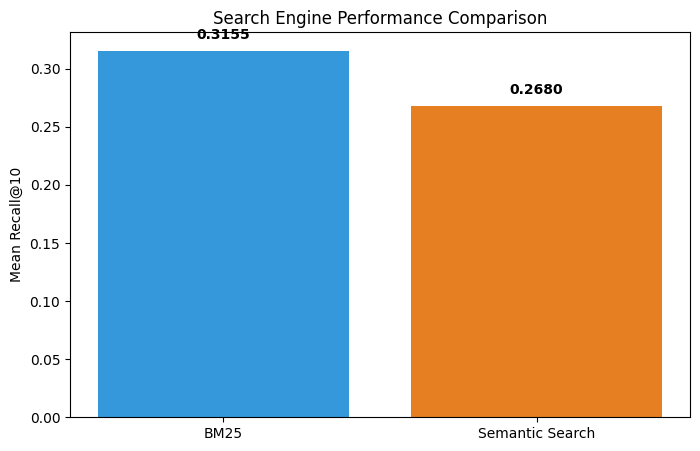

In [19]:
# Visualize comparison
import matplotlib.pyplot as plt

methods = ['BM25', 'Semantic Search']
scores = [np.mean(bm25_recalls), np.mean(semantic_recalls)]

plt.figure(figsize=(8, 5))
plt.bar(methods, scores, color=['#3498db', '#e67e22'])
plt.ylabel('Mean Recall@10')
plt.title('Search Engine Performance Comparison')
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

---

## Task 5: Compare Embedding Models (20 points)

### 5a. Embed products with two different models (10 pts)

Compare embeddings from:
- `BAAI/bge-base-en-v1.5`
- `sentence-transformers/all-mpnet-base-v2`

In [20]:
# Load the two embedding models
model_bge = SentenceTransformer('BAAI/bge-small-en-v1.5')
model_mpnet = SentenceTransformer('all-mpnet-base-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [21]:
# Embed products with both models
print("Generating BGE embeddings...")
embeddings_bge = model_bge.encode(products_sample['embed_text'].tolist(), show_progress_bar=True)

print("Generating MPNet embeddings...")
embeddings_mpnet = model_mpnet.encode(products_sample['embed_text'].tolist(), show_progress_bar=True)

Generating BGE embeddings...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Generating MPNet embeddings...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

### 5b. Compare search results between models (10 pts)

Evaluate both models on the same queries and analyze differences.

In [31]:
import numpy as np

print("bge model dim:", model_bge.get_sentence_embedding_dimension())
print("mpnet model dim:", model_mpnet.get_sentence_embedding_dimension())

E_bge = np.array(embeddings_bge)
E_mpnet = np.array(embeddings_mpnet)

print("embeddings_bge shape:", E_bge.shape)
print("embeddings_mpnet shape:", E_mpnet.shape)


bge model dim: 768
mpnet model dim: 768
embeddings_bge shape: (5000, 384)
embeddings_mpnet shape: (5000, 768)


In [32]:
# Force embeddings into (num_docs, dim) format

bge_dim = model_bge.get_sentence_embedding_dimension()
mpnet_dim = model_mpnet.get_sentence_embedding_dimension()

E_bge = np.array(embeddings_bge)
E_mpnet = np.array(embeddings_mpnet)

if E_bge.shape[0] == bge_dim and E_bge.shape[1] != bge_dim:
    E_bge = E_bge.T

if E_mpnet.shape[0] == mpnet_dim and E_mpnet.shape[1] != mpnet_dim:
    E_mpnet = E_mpnet.T

print("Fixed embeddings_bge:", E_bge.shape)
print("Fixed embeddings_mpnet:", E_mpnet.shape)


Fixed embeddings_bge: (5000, 384)
Fixed embeddings_mpnet: (5000, 768)


In [33]:
test_queries = ["comfortable sofa", "star wars rug", "modern coffee table"]

for q in test_queries:
    print("\n" + "="*40)
    print("Query:", q)

    res_bge = semantic_search(q, model_bge, E_bge, products_sample, k=5)
    res_mpnet = semantic_search(q, model_mpnet, E_mpnet, products_sample, k=5)

    print("\nBGE top results:")
    display(res_bge[["product_name"]].head())

    print("\nMPNet top results:")
    display(res_mpnet[["product_name"]].head())




Query: comfortable sofa


ValueError: shapes (1,768) and (384,5000) not aligned: 768 (dim 1) != 384 (dim 0)

In [ ]:
# Visualize model comparison with a scatter plot
# X-axis: BGE Recall@10, Y-axis: MPNet Recall@10


---

## Task 6: Git Submission (5 points)

Submit your work using the Git workflow:

- [ ] Create a new branch called `homework-4`
- [ ] Commit your work with a meaningful message
- [ ] Push to GitHub
- [ ] Create a Pull Request
- [ ] Merge the PR to main
- [ ] Submit the `.ipynb` file on Blackboard

The TA will verify your submission by checking the merged PR on GitHub.